# EDA Fase 2: Análisis Geoespacial y Topográfico
Este notebook se encarga de la geografía del riesgo.
El objetivo es visualizar las áreas de mayor densidad histórica de fuegos (KDE) y comprobar estadísticamente el impacto del relieve (Solana vs Umbría) en la severidad final de los incendios.

**Decisiones Metodológicas:**
1. Conversión de coordenadas a GeoDataFrame.
2. Discretización geomorfológica de la orientación (Solana/Umbría/Este/Oeste).
3. Prueba no paramétrica de Mann-Whitney U para superar el obstáculo de la asimetría de la superficie quemada (leyes de potencia).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from pathlib import Path
from scipy import stats
import warnings
warnings.filterwarnings('ignore')


sns.set_theme(style="white", context="paper", font_scale=1.2)
plt.rcParams['figure.figsize'] = (12, 8)


FIG_DIR = Path("../entregas/figuras")
FIG_DIR.mkdir(parents=True, exist_ok=True)


df = pd.read_csv('../datos/processed/07_dataset_final_TOPOGRAFICO.csv', sep=';', decimal=',') 
df = df.drop_duplicates(subset=['lat', 'lon', 'fecha_ini', 'Superficie_Total_Real'])


cols_numericas = ['Superficie_Total_Real', 'lat', 'lon', 'pendiente', 'orientacion']
for col in cols_numericas:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '.'), errors='coerce')


df = df.dropna(subset=['lat', 'lon', 'Superficie_Total_Real', 'orientacion'])


df['log_superficie'] = np.log1p(df['Superficie_Total_Real'])


df['es_GIF'] = df['Superficie_Total_Real'] > 500

print(f"Dataset cargado y depurado para análisis espacial con {len(df)} registros.")


Dataset cargado y depurado para análisis espacial con 4443 registros.


## 1. Mapeo de Densidad Espacial (KDE)
Análisis de clústeres históricos para identificar los puntos calientes o "hotspots" de ignición en la Comunitat Valenciana.


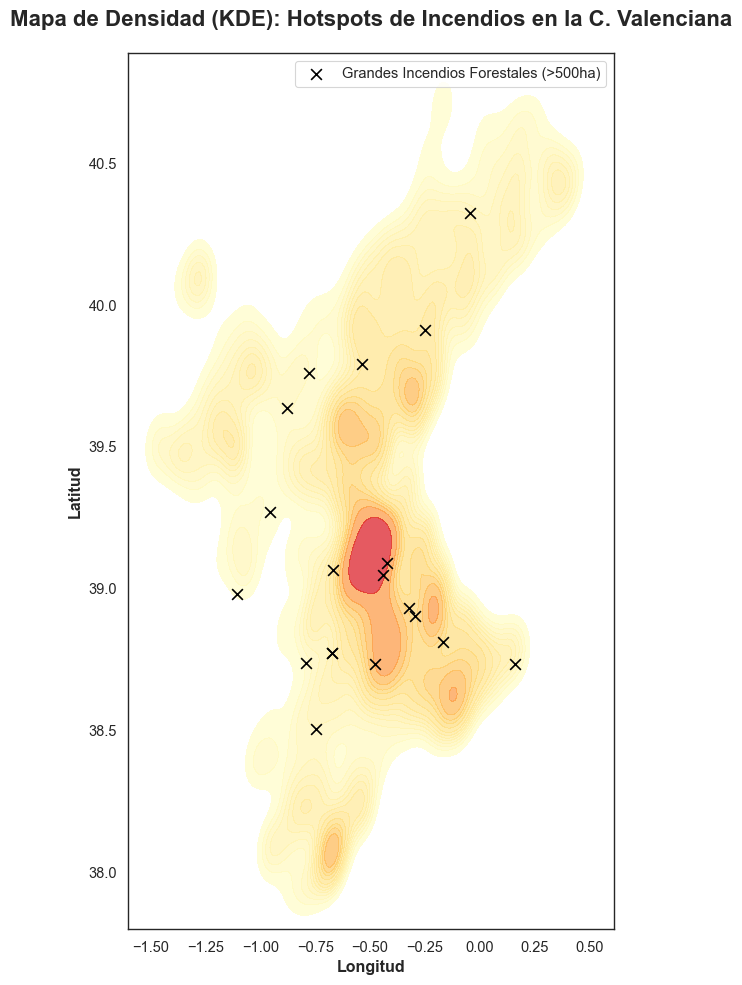

In [2]:

gdf = gpd.GeoDataFrame(
    df, 
    geometry=gpd.points_from_xy(df.lon, df.lat), 
    crs="EPSG:4326"
)

fig, ax = plt.subplots(figsize=(10, 10))


sns.kdeplot(
    x=gdf.geometry.x, 
    y=gdf.geometry.y, 
    cmap='YlOrRd', 
    fill=True, 
    bw_adjust=0.5, 
    alpha=0.7, 
    ax=ax,
    levels=15
)


gifs = gdf[gdf['es_GIF'] == True]
gifs.plot(ax=ax, color='black', marker='x', markersize=60, label='Grandes Incendios Forestales (>500ha)')

ax.set_title('Mapa de Densidad (KDE): Hotspots de Incendios en la C. Valenciana', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Longitud', fontweight='bold')
ax.set_ylabel('Latitud', fontweight='bold')
ax.legend()


ax.set_xlim(gdf.geometry.x.min() - 0.1, gdf.geometry.x.max() + 0.1)
ax.set_ylim(gdf.geometry.y.min() - 0.1, gdf.geometry.y.max() + 0.1)

plt.tight_layout()
plt.savefig(FIG_DIR / '06_KDE_Espacial.png', dpi=300, bbox_inches='tight')
plt.show()


## 2. Análisis Estadístico de Orientación (Solana vs Umbría)
Las laderas varían su estrés hídrico radicalmente en función de las horas de insolación diaria. Vamos a clasificar los grados continuos en cuadrantes funcionales.


In [3]:
def clasificar_orientacion(grados):
    if grados < 0 or pd.isna(grados):
        return 'Llano/Indefinido'
    
    
    if grados >= 315 or grados < 45:
        return 'Umbría (N/NO/NE)'
    
    elif 45 <= grados < 135:
        return 'Este (E)'
    
    elif 135 <= grados < 225:
        return 'Solana (S/SO/SE)'
    
    elif 225 <= grados < 315:
        return 'Oeste (O)'

df['tipo_ladera'] = df['orientacion'].apply(clasificar_orientacion)


df_relieve = df[df['tipo_ladera'] != 'Llano/Indefinido'].copy()


stats_ladera = df_relieve.groupby('tipo_ladera').agg(
    frecuencia=('Campania', 'count'),
    superficie_total=('Superficie_Total_Real', 'sum'),
    superficie_mediana=('Superficie_Total_Real', 'median')
).reset_index()

display(stats_ladera)


,tipo_ladera,frecuencia,superficie_total,superficie_mediana
0,Este (E),1267,20301.0313,0.1
1,Oeste (O),984,21226.7238,0.1
2,Solana (S/SO/SE),1166,6768.8652,0.1
3,Umbría (N/NO/NE),989,32984.3049,0.1


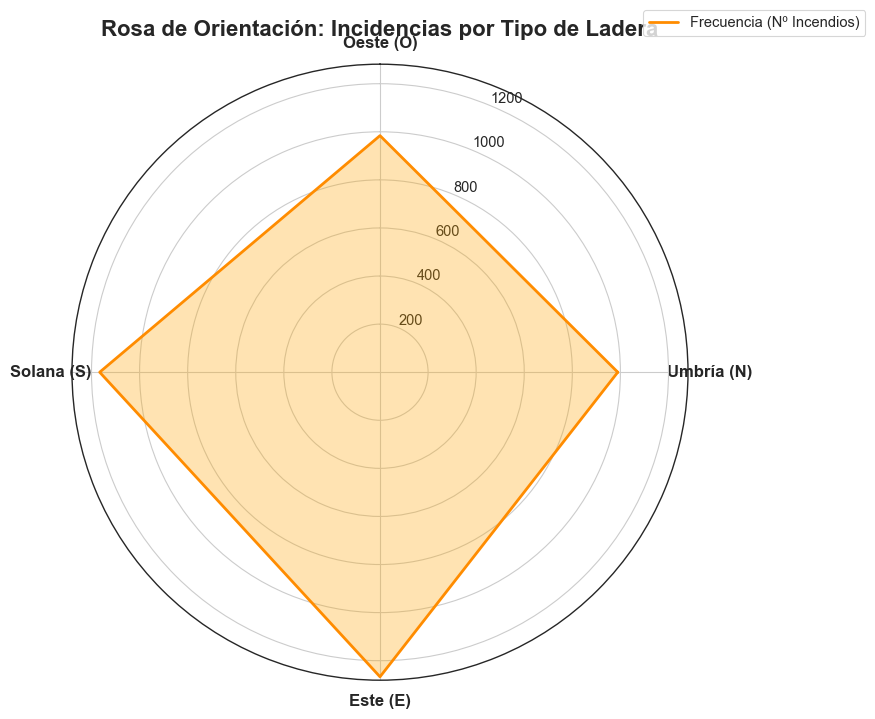

In [4]:

orden = ['Umbría (N/NO/NE)', 'Este (E)', 'Solana (S/SO/SE)', 'Oeste (O)']
stats_ladera['tipo_ladera'] = pd.Categorical(stats_ladera['tipo_ladera'], categories=orden, ordered=True)
stats_ladera = stats_ladera.sort_values('tipo_ladera')

angles = np.linspace(np.pi/2, 2*np.pi + np.pi/2, 4, endpoint=False).tolist()
angles += angles[:1] 
freq = stats_ladera['frecuencia'].tolist()
freq += freq[:1]

sup = (stats_ladera['superficie_total'] / stats_ladera['superficie_total'].max()).tolist() # Normalizado para visualizar ambas métricas
sup += sup[:1]
sup_real = stats_ladera['superficie_total'].tolist()
sup_real += sup_real[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))


ax.set_theta_direction(-1)
ax.set_theta_offset(np.pi / 2.0)

ax.plot(angles, freq, color='darkorange', linewidth=2, linestyle='solid', label='Frecuencia (Nº Incendios)')
ax.fill(angles, freq, color='orange', alpha=0.3)


ax.set_xticks(angles[:-1])
ax.set_xticklabels(['Umbría (N)', 'Este (E)', 'Solana (S)', 'Oeste (O)'], fontsize=12, fontweight='bold')

plt.title('Rosa de Orientación: Incidencias por Tipo de Ladera', size=16, fontweight='bold', pad=20)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.savefig(FIG_DIR / '07_Rosa_Orientacion.png', dpi=300, bbox_inches='tight')
plt.show()


## 3. Contraste de Hipótesis: Severidad Solana vs Umbría
Emplearemos la prueba estadística no paramétrica de **Mann-Whitney U** para determinar si las laderas orientadas al sur (Solana) sufren sistemáticamente daños más severos debido a la mayor sequedad del combustible, mitigando la enorme varianza de la superficie mediante el test de rangos.


=== TEST DE HIPÓTESIS: MANN-WHITNEY U ===
H0: No hay diferencia en la severidad entre Solana y Umbría.
H1: La severidad (log_superficie) es mayor en Solana que en Umbría.
Estadístico U: 579811.0
Valor p: 4.111673e-01
----------------------------------------
Resultado: NO SE RECHAZA H0. No hay evidencia concluyente de que la solana sea peor.


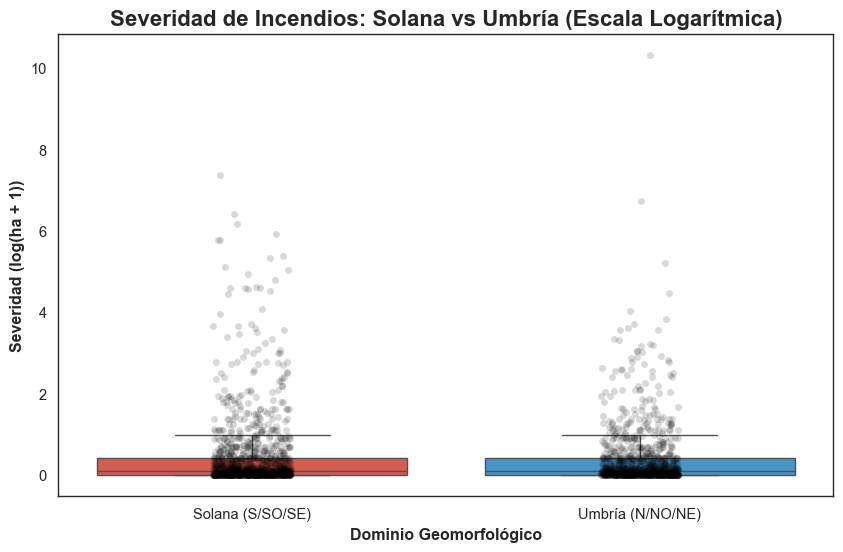

In [5]:
solana = df_relieve[df_relieve['tipo_ladera'] == 'Solana (S/SO/SE)']['log_superficie']
umbria = df_relieve[df_relieve['tipo_ladera'] == 'Umbría (N/NO/NE)']['log_superficie']


stat, p_value = stats.mannwhitneyu(solana, umbria, alternative='greater')

print("=== TEST DE HIPÓTESIS: MANN-WHITNEY U ===")
print("H0: No hay diferencia en la severidad entre Solana y Umbría.")
print("H1: La severidad (log_superficie) es mayor en Solana que en Umbría.")
print(f"Estadístico U: {stat}")
print(f"Valor p: {p_value:.6e}")
print("-" * 40)
if p_value < 0.05:
    print("Resultado: Se RECHAZA H0. Hay evidencia estadística significativa de que los incendios en solana son más severos.")
else:
    print("Resultado: NO SE RECHAZA H0. No hay evidencia concluyente de que la solana sea peor.")


fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=df_relieve[df_relieve['tipo_ladera'].isin(['Solana (S/SO/SE)', 'Umbría (N/NO/NE)'])], 
    x='tipo_ladera', 
    y='log_superficie', 
    palette=['#e74c3c', '#3498db'],
    showfliers=False, 
    ax=ax
)
sns.stripplot(
    data=df_relieve[df_relieve['tipo_ladera'].isin(['Solana (S/SO/SE)', 'Umbría (N/NO/NE)'])], 
    x='tipo_ladera', 
    y='log_superficie', 
    color='black', 
    alpha=0.15, 
    jitter=True,
    ax=ax
)

plt.title('Severidad de Incendios: Solana vs Umbría (Escala Logarítmica)', fontsize=16, fontweight='bold')
plt.xlabel('Dominio Geomorfológico', fontweight='bold')
plt.ylabel('Severidad (log(ha + 1))', fontweight='bold')

plt.savefig(FIG_DIR / '08_Distribucion_Solana_Umbria.png', dpi=300, bbox_inches='tight')
plt.show()
